# Exhibit: Forecast Errors, Revisited

*Workshop 2 exhibit — **Structural Change and Expectations in Macroeconomics and Finance** (University of Copenhagen, Autumn 2026).*

## 1. The relation

This is the relation you know from Workshop 1: the **forecast-error regression**,

$$e_{t+1} = \alpha + \beta \, \text{revision}_t + u_{t+1},$$

where $e_{t+1}$ is professional forecasters' inflation forecast error and the regressor is their own forecast revision — something they knew at the time. The rational expectations hypothesis (REH, in its full-information form FIRE) predicts $\alpha = \beta = 0$: forecast errors should be unbiased and unpredictable. The stakes: this regression is the workhorse test behind a large literature on to represent expectations (Coibion and Gorodnichenko 2015; the survey you read for today, CGK 2018, Section 4).

In Workshop 1 you saw the full-sample verdict ($\hat\beta \approx 1.1$, significant — FIRE rejected) and a first look at three subsamples. Today's exhibit digs into the stability question properly.

**Data:** SPF mean forecasts of one-year-ahead GDP-deflator inflation and first-release actuals, 1970Q2–2024Q2 (the Workshop 1 dataset).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

BLUE, RED, TEAL, GREY = "#006BA2", "#DB444B", "#3EBCD2", "#758D99"
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y", "grid.alpha": 0.35,
    "axes.titlelocation": "left", "axes.titlesize": 12, "font.size": 11,
})

def load(name):
    try:
        df = pd.read_csv(f"../data/{name}", index_col="quarter")
    except FileNotFoundError:
        base = "https://raw.githubusercontent.com/mortentabor/structural-change-seminar/main/data/"
        df = pd.read_csv(base + name, index_col="quarter")
    df.index = pd.PeriodIndex(df.index, freq="Q")
    return df

fe = load("forecast_errors.csv").dropna(subset=["error_avg", "revision_avg"])
fe.tail(3)

,F_avg,pi_avg,error_avg,revision_avg,pi_lag,error_avg_h1,error_avg_h2,error_avg_h3,revision_avg_h1,revision_avg_h2,revision_avg_h3
quarter,,,,,,,,,,,
2023Q4,2.141275,2.360500,0.219225,-0.523275,1.4806,1.0144,0.57990,0.261633,-0.6273,-0.56745,-0.531367
2024Q1,2.558100,2.515650,-0.042450,0.403400,3.1213,-0.6106,-0.67340,-0.491333,0.7560,0.55865,0.445500
2024Q2,2.378950,2.439775,0.060825,-0.011950,2.2829,-0.5577,-0.36445,0.225800,-0.1785,-0.06725,-0.078867


## 2. The full-sample estimate

In [2]:
def fit_cg(d):
    return sm.OLS(d["error_avg"], sm.add_constant(d["revision_avg"])).fit(
        cov_type="HAC", cov_kwds={"maxlags": 4})

full = fit_cg(fe)
print(f"Sample: {fe.index.min()}–{fe.index.max()}  (n = {int(full.nobs)})")
print(full.summary().tables[1])

Sample: 1970Q2–2024Q2  (n = 216)
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.0247      0.127     -0.195      0.846      -0.273       0.224
revision_avg     1.1198      0.405      2.765      0.006       0.326       1.914


$\hat\beta = 1.12$, significant; $\hat\alpha \approx 0$. The full sample rejects unpredictability but not unbiasedness — that was Workshop 1's headline.

## 3. Is it stable? Your turn first

You saw three subsamples in Workshop 1. Now make the splits **your own**: change the dictionary — move the cuts, add periods, try decades — rerun, and watch both coefficients.

In [3]:
SUBSAMPLES = {
    "1970s":            ("1970Q2", "1979Q4"),
    "Great Moderation": ("1980Q1", "2019Q4"),
    "Post-2020":        ("2020Q1", "2024Q2"),
}

rows = []
for name, (start, end) in SUBSAMPLES.items():
    r = fit_cg(fe.loc[start:end])
    rows.append({"sample": name,
                 "alpha": r.params.iloc[0], "se(alpha)": r.bse.iloc[0], "p(alpha)": r.pvalues.iloc[0],
                 "beta": r.params.iloc[1], "se(beta)": r.bse.iloc[1], "p(beta)": r.pvalues.iloc[1],
                 "n": int(r.nobs)})
pd.DataFrame(rows).round(3)

,sample,alpha,se(alpha),p(alpha),beta,se(beta),p(beta),n
0,1970s,0.527,0.352,0.134,1.166,0.634,0.066,38
1,Great Moderation,-0.402,0.086,0.000,0.073,0.144,0.609,160
2,Post-2020,1.188,0.701,0.090,1.198,0.537,0.026,18


### Now compare with a formal test

Your splits were chosen by you, knowing the history. The **Bai–Perron test** lets the *data* choose the break dates (how it works is Workshop 3). Applied to this regression, it finds **six break dates — seven regimes**:

**1974Q2, 1977Q2, 1980Q2, 1998Q4, 2019Q1, 2021Q4**

Notice: three breaks crowd into the turbulent 1970s–1980; a long quiet stretch follows; then breaks reappear at 2019–2021. And across the long middle regime (1998Q4–2018Q4), the estimated $\beta$ is essentially zero — while in the short 2019Q1–2021Q3 regime it exceeds 3. How close were your own splits?

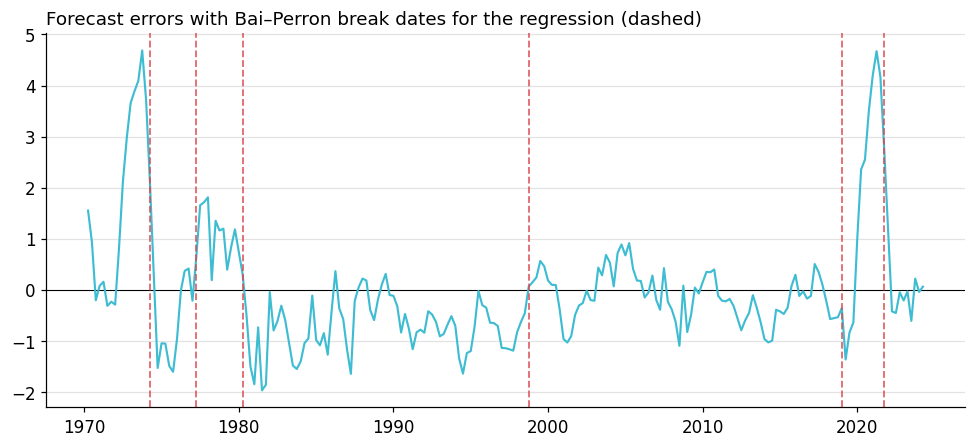

In [4]:
BP_BREAKS = ["1974Q2", "1977Q2", "1980Q2", "1998Q4", "2019Q1", "2021Q4"]  # Bai-Perron, precomputed

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.axhline(0, color="black", lw=0.7)
ax.plot(fe.index.to_timestamp(), fe["error_avg"], color=TEAL, lw=1.4)
for b in BP_BREAKS:
    ax.axvline(pd.Period(b, freq="Q").to_timestamp(), color=RED, lw=1.2, ls="--", alpha=0.8)
ax.set_title("Forecast errors with Bai–Perron break dates for the regression (dashed)")
plt.tight_layout()
plt.show()

### Try the regime estimates yourself

The Bai–Perron procedure does not only *date* the breaks. Given the dates, the regime-by-regime estimates are nothing more mysterious than **subsample estimates with the splits placed at the estimated break dates** – and you already have the tool.

**Run the next cell** (it redefines `SUBSAMPLES` as the seven regimes), **then scroll up and rerun the estimates cell in Section 3.**

Check the claims above: the long 1998Q4–2018Q4 regime should give $\hat\beta \approx 0$, the short 2019Q1–2021Q3 regime $\hat\beta > 3$.

One caution as you read your table: several regimes are only 11–12 quarters long, so their estimates come with wide standard errors. How much can we really conclude from a regime that short? That inference question is itself a paper – and part of Workshop 3.

In [5]:
# The seven Bai-Perron regimes. Run this cell, then rerun the estimates cell in Section 3.
SUBSAMPLES = {
    "1970Q2–1974Q1": ("1970Q2", "1974Q1"),
    "1974Q2–1977Q1": ("1974Q2", "1977Q1"),
    "1977Q2–1980Q1": ("1977Q2", "1980Q1"),
    "1980Q2–1998Q3": ("1980Q2", "1998Q3"),
    "1998Q4–2018Q4": ("1998Q4", "2018Q4"),
    "2019Q1–2021Q3": ("2019Q1", "2021Q3"),
    "2021Q4–2024Q2": ("2021Q4", "2024Q2"),
}

## 4. What could a paper deliver?

You have now seen that the relation is not stable. **That, by itself, is not yet a research question.** "Is X stable? — No" is a finding, not a paper. The interesting paper starts with what you build *on top of* the finding. Four types of questions you can build:

1. **Timing / episodes** — the breaks cluster in the 1970s–1980 and at 2019–2021. Are systematic forecast errors concentrated in the great inflationary episodes — and is the *same* true in other countries' surveys, or for other variables?
2. **Source / mechanism** — *what* changed at those dates: the forecasters' behavior, or the inflation process they were forecasting? Can you tell the two apart?
3. **Interpretation / inference** — if $\alpha$ and $\beta$ shift between regimes, can the forecast-error regression test rational expectations at all? What is the full-sample estimate an average *of* — and does any of the explanations in CGK's Section 4 survive once the instability is taken seriously?
4. **Consequences / practice** — the errors turn biased and predictable exactly in the turbulent episodes. What does that mean for central banks and markets that rely on these forecasts when it matters most?

**The "This paper…" exercise.** A research question is specific when you can state what the paper *delivers*. Compare (on a relation that is *not* one of today's exhibits):

> *Weak:* "This paper examines whether Okun's law is stable."
>
> *Strong:* "This paper shows that Okun's law held in every US recession since 1960 except 2020, and asks what made the COVID labor market different."

The strong version states a deliverable and why it is interesting — even before the analysis exists.

**Your task (in class):** write one or two **"This paper…"** sentences for this exhibit. Be specific: what does your paper show, ask, or deliver?

## 5. Further reading

If this exhibit grabbed you, start here:

- Coibion, O., and Gorodnichenko, Y. (2015). "Information Rigidity and the Expectation Formation Process." *American Economic Review*, 105(8) — the workhorse regression and the information-rigidity reading of $\beta > 0$.
- Bordalo, P., Gennaioli, N., Ma, Y., and Shleifer, A. (2020). "Overreaction in Macroeconomic Expectations." *American Economic Review*, 110(9) — the behavioral reading, at the individual-forecaster level.
- Rossi, B., and Sekhposyan, T. (2016). "Forecast Rationality Tests in the Presence of Instabilities." *Journal of Applied Econometrics*, 31(3) — what instability does to rationality tests themselves.
- Hajdini, I., and Kurmann, A. (2024). "Predictable Forecast Errors in Full-Information Rational Expectations Models with Regime Shifts." Working paper — fully rational forecasters, recurring regimes, predictable errors.
- Frydman, R., and Tabor, M. N. (2025). INET Center Working Papers 1–2 — nonrepetitive structural change as the account of exactly the shifting $(\alpha, \beta)$ pattern you found above.